# Compare fixed annotations

Three-way comparison of partition assignments for the presolved matrix:
- **Original**: annotation of the original model, transferred onto the presolved matrix
- **Fixed**: annotation of the original model re-run with removed variables fixed to their
  prior partition, then transferred onto the presolved matrix
- **Presolved**: annotation found by running the hypergraph partitioner directly on the
  presolved model

Change `MODEL_NAME` parameters in the cell below to switch models.

In [2]:
from typing import Tuple

regions:    int                  = 25
resolution: int                  = 1
range:      Tuple[float, float]  = (0.5, 1)
cf:         float                = None
is_mip:     bool                 = False
has_obj:    bool                 = True
hypergraph = 'col'
var_dense = 200

MODEL_NAME = (
    f'r{regions}_res{resolution}'
    f'_f{range[0]:.4f}_t{range[1]:.4f}'
    + (f'_cf{cf}' if cf else '')
    + ('_mip' if is_mip  else '')
    + ('_obj' if has_obj else '')
)

# MODEL_NAME = 'benchmarks/MIPLIB/30n20b8'
# regions = 6

print(MODEL_NAME)

MAX_MPI_PROCS = 2  # cap MPI processes to avoid OOM


r25_res1_f0.5000_t1.0000_obj


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS, PAPILO_PRESOLVED_MODELS, DATA
from pipstools.io import read_gdx
from src.detection.annotation import annotate_mps, read_annotation
from src.detection.visualisation import (
    transfer_partition,
    plot_partition,
    compute_partition_stats,
    render_stats,
    read_integer_col_names,
)

_suffix = ('_mip' if is_mip else '') + ('_obj' if has_obj else '')

ANNOTATIONS_ORIG      = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/original')
ANNOTATIONS_PRESOLVED = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/presolved')
ANNOTATIONS_FIXED     = Path(f'/data/energy-system-preprocessing/annotations{_suffix}/fixed')
BLOCKS_BASE           = Path('/data/energy-system-preprocessing/blocks')

gdx_orig      = ANNOTATIONS_ORIG      / f'{MODEL_NAME}.gdx'
gdx_presolved = ANNOTATIONS_PRESOLVED / f'{MODEL_NAME}.gdx'
gdx_fixed     = ANNOTATIONS_FIXED     / f'{MODEL_NAME}.gdx'
mps_orig      = MODELS / MODEL_NAME / 'original.mps'
mps_pre       = DATA / "presolve" / "static" / "domcol" / MODEL_NAME / 'reduced.mps'

# mps_pre       = PAPILO_PRESOLVED_MODELS / MODEL_NAME / 'reduced.mps'

BLOCKS_ORIG  = BLOCKS_BASE / MODEL_NAME / 'original'
BLOCKS_PRE   = BLOCKS_BASE / MODEL_NAME / 'reduced'
BLOCKS_FIXED = BLOCKS_BASE / MODEL_NAME / 'fixed'

for p in (mps_orig, mps_pre, gdx_orig, gdx_presolved):
    if not p.exists():
        raise FileNotFoundError(
            f'{p} not found — run experiments/annotation/annotate_models.ipynb first'
        )

print(f'Model    : {MODEL_NAME}')
print(f'Orig GDX : {gdx_orig}')
print(f'Pre GDX  : {gdx_presolved}')
print(f'Fixed GDX: {gdx_fixed}  (will be generated)')
print(f'MPS orig : {mps_orig}')
print(f'MPS pre  : {mps_pre}')


Model    : r25_res1_f0.5000_t1.0000_obj
Orig GDX : /data/energy-system-preprocessing/annotations_obj/original/r25_res1_f0.5000_t1.0000_obj.gdx
Pre GDX  : /data/energy-system-preprocessing/annotations_obj/presolved/r25_res1_f0.5000_t1.0000_obj.gdx
Fixed GDX: /data/energy-system-preprocessing/annotations_obj/fixed/r25_res1_f0.5000_t1.0000_obj.gdx  (will be generated)
MPS orig : /data/energy-system-preprocessing/models/r25_res1_f0.5000_t1.0000_obj/original.mps
MPS pre  : /data/energy-system-preprocessing/presolve/static/domcol/r25_res1_f0.5000_t1.0000_obj/reduced.mps


## Generate original and presolved annotations

In [3]:
import time
from src.config import MODELS, PAPILO_PRESOLVED_MODELS
from pipstools.io import read_gdx
from src.detection.annotation import annotate_mps, read_annotation
from src.detection.visualisation import (
    transfer_partition,
    plot_partition,
    compute_partition_stats,
    render_stats,
    read_integer_col_names,
)

# Original annotation
t0 = time.perf_counter()
cols_orig, rows_orig, _ = annotate_mps(
    mps_path=mps_orig,
    k=regions,
    output_gdx=gdx_orig,
    hypergraph=hypergraph,
    var_dense=var_dense,
    overwrite=True,
)
orig_wall_time = time.perf_counter() - t0
print(f'Original annotation:  {len(cols_orig)} vars, {len(rows_orig)} rows  ({orig_wall_time:.1f}s)')

# Presolved annotation
t0 = time.perf_counter()
cols_pre_ann, rows_pre_ann, _ = annotate_mps(
    mps_path=mps_pre,
    k=regions,
    output_gdx=gdx_presolved,
    hypergraph=hypergraph,
    var_dense=var_dense,
    overwrite=True,
)
pre_wall_time = time.perf_counter() - t0
print(f'Presolved annotation: {len(cols_pre_ann)} vars, {len(rows_pre_ann)} rows  ({pre_wall_time:.1f}s)')

# Full GDX read for A_pre (needed for plotting)
A_pre, cols_pre, rows_pre, objcoef_pre = read_gdx(gdx_presolved)

# Integer variable names
int_cols_orig = read_integer_col_names(mps_orig) if mps_orig.exists() else set()
int_cols_pre  = read_integer_col_names(mps_pre)  if mps_pre.exists()  else set()

print(f'\nA_pre: {len(A_pre)} nnz  ({len(int_cols_pre)} integer cols)')


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Annotating a model with 1108267 rows, 1217919 columns, 4504984 nonzeros
Detected 203 dense columns
Detected 0 dense rows
Detected 889140 rows with a single column
Partitioning the reduced col matrix with 1217716 rows, 219127 columns, 2763931 nonzeros
Initializing mtkahypar
Creating hypergraph
Partitioning hypergraph
*******************************************************************************
*                            Partitioning Context                             *
*******************************************************************************
Partitioning Parameters:
  Hypergraph:                         
  Input File Format:                  hMetis (-> hypergraph)
  Preset:                             quality
  k:                                  25
  epsilon:                            0.001
  Objective:                          soed
  seed:                               0
  Number of V-Cycl

[WARNING] Mt-KaHyPar is already initialized


*******************************************************************************
*                            Partitioning Context                             *
*******************************************************************************
Partitioning Parameters:
  Hypergraph:                         
  Input File Format:                  hMetis (-> hypergraph)
  Preset:                             quality
  k:                                  25
  epsilon:                            0.001
  Objective:                          soed
  seed:                               0
  Number of V-Cycles:                 0
  Ignore HE Size Threshold:           1000
  Large HE Size Threshold:            50000
-------------------------------------------------------------------------------
Preprocessing Parameters:
  Use Community Detection:            true
  Disable C. D. for Mesh Graphs:      true

  Community Detection Parameters:
    Edge Weight Function:                degree
    Maximum Louvain

## Generate fixed annotation

Re-runs hypergraph partitioning on the **original** model with variables removed by
PaPILO presolve fixed to their prior partition assignment. `overwrite=True` always
regenerates this annotation.

In [4]:
import time

t0 = time.perf_counter()
cols_fixed, rows_fixed, _ = annotate_mps(
    mps_path=mps_orig,
    k=regions,
    output_gdx=gdx_fixed,
    hypergraph=hypergraph,
    var_dense=var_dense,
    overwrite=True,
    annotation_gdx=gdx_orig,
    mps_path_reduced=mps_pre,
)
annotation_wall_time = time.perf_counter() - t0

print(f'Fixed annotation: {len(cols_fixed)} vars, {len(rows_fixed)} rows')
print(f'Annotation wall time: {annotation_wall_time:.1f}s')
print(cols_fixed.group_by('partition').len().sort('partition'))


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Number of MI entries in BOUNDS section is 51
Number of PL entries in BOUNDS section is 961286
Derived fixed vertices from presolve diff: 37431 removed variables, 37431 removed constraints (74862 total)
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Annotating a model with 1108267 rows, 1217919 columns, 4504984 nonzeros
Detected 203 dense columns
Detected 0 dense rows
Detected 889140 rows with a single column
Partitioning the reduced col matrix with 1217716 rows, 219127 columns, 2763931 nonzeros
Initializing mtkahypar
Creating hypergraph
Fixed vertices: 74862 provided, 37430 resolved by join, 37430 applied
Partitioning hypergraph


[WARNING] Mt-KaHyPar is already initialized


*******************************************************************************
*                            Partitioning Context                             *
*******************************************************************************
Partitioning Parameters:
  Hypergraph:                         
  Input File Format:                  hMetis (-> hypergraph)
  Preset:                             quality
  k:                                  25
  epsilon:                            0.001
  Objective:                          soed
  seed:                               0
  Number of V-Cycles:                 0
  Ignore HE Size Threshold:           1000
  Large HE Size Threshold:            50000
-------------------------------------------------------------------------------
Preprocessing Parameters:
  Use Community Detection:            true
  Disable C. D. for Mesh Graphs:      true

  Community Detection Parameters:
    Edge Weight Function:                degree
    Maximum Louvain

## Transfer partition labels onto the presolved matrix

Both the original and fixed annotations describe the **original** model, so both
require a label transfer (`transfer_partition`) to align them with the presolved
matrix's variable/constraint ordering.

In [5]:
import polars as pl
from pipstools.utils import get_blocks_ids

# Transfer original partition labels onto the presolved matrix
cols_orig_on_pre, rows_orig_on_pre = transfer_partition(
    cols_pre, rows_pre,
    cols_orig, rows_orig,
)

# Transfer fixed partition labels onto the presolved matrix (also an original-model annotation)
cols_fixed_on_pre, rows_fixed_on_pre = transfer_partition(
    cols_pre, rows_pre,
    cols_fixed, rows_fixed,
)

# Identify originally-linking rows/cols and their fate after presolve
_, orig_link_first, orig_link_last = get_blocks_ids(rows_orig, cols_orig)
orig_linking_row_names = set(
    rows_orig.filter(pl.col('partition').is_in(orig_link_last + orig_link_first))['name'].to_list()
)
orig_linking_col_names = set(
    cols_orig.filter(pl.col('partition').is_in(orig_link_first))['name'].to_list()
)

presolved_row_names = set(rows_pre['name'].to_list())
presolved_col_names = set(cols_pre['name'].to_list())

surviving_linking_rows  = orig_linking_row_names & presolved_row_names
eliminated_linking_rows = orig_linking_row_names - presolved_row_names
surviving_linking_cols  = orig_linking_col_names & presolved_col_names
eliminated_linking_cols = orig_linking_col_names - presolved_col_names

int_cols_orig_on_pre  = int_cols_orig & presolved_col_names
int_cols_fixed_on_pre = int_cols_orig & presolved_col_names

stats_orig  = compute_partition_stats(A_pre, cols_orig_on_pre,  rows_orig_on_pre,
                                       integer_col_names=int_cols_orig_on_pre)
stats_fixed = compute_partition_stats(A_pre, cols_fixed_on_pre, rows_fixed_on_pre,
                                       integer_col_names=int_cols_fixed_on_pre)
stats_pre   = compute_partition_stats(A_pre, cols_pre, rows_pre,
                                       integer_col_names=int_cols_pre)

print('Original labels on presolved (col partition counts):')
print(cols_orig_on_pre.group_by('partition').len().sort('partition'))
print()
print('Fixed labels on presolved (col partition counts):')
print(cols_fixed_on_pre.group_by('partition').len().sort('partition'))
print()
print('Presolved labels (col partition counts):')
print(cols_pre.group_by('partition').len().sort('partition'))


Original labels on presolved (col partition counts):
shape: (26, 2)
┌───────────┬───────┐
│ partition ┆ len   │
│ ---       ┆ ---   │
│ u32       ┆ u32   │
╞═══════════╪═══════╡
│ 1         ┆ 204   │
│ 2         ┆ 47407 │
│ 3         ┆ 47117 │
│ 4         ┆ 47169 │
│ 5         ┆ 47034 │
│ …         ┆ …     │
│ 22        ┆ 47258 │
│ 23        ┆ 47206 │
│ 24        ┆ 46910 │
│ 25        ┆ 47170 │
│ 26        ┆ 47334 │
└───────────┴───────┘

Fixed labels on presolved (col partition counts):
shape: (26, 2)
┌───────────┬───────┐
│ partition ┆ len   │
│ ---       ┆ ---   │
│ u32       ┆ u32   │
╞═══════════╪═══════╡
│ 1         ┆ 204   │
│ 2         ┆ 47367 │
│ 3         ┆ 47096 │
│ 4         ┆ 47694 │
│ 5         ┆ 47122 │
│ …         ┆ …     │
│ 22        ┆ 47131 │
│ 23        ┆ 47180 │
│ 24        ┆ 46928 │
│ 25        ┆ 47007 │
│ 26        ┆ 47178 │
└───────────┴───────┘

Presolved labels (col partition counts):
shape: (26, 2)
┌───────────┬───────┐
│ partition ┆ len   │
│ ---       ┆ ---

## Stacked comparison

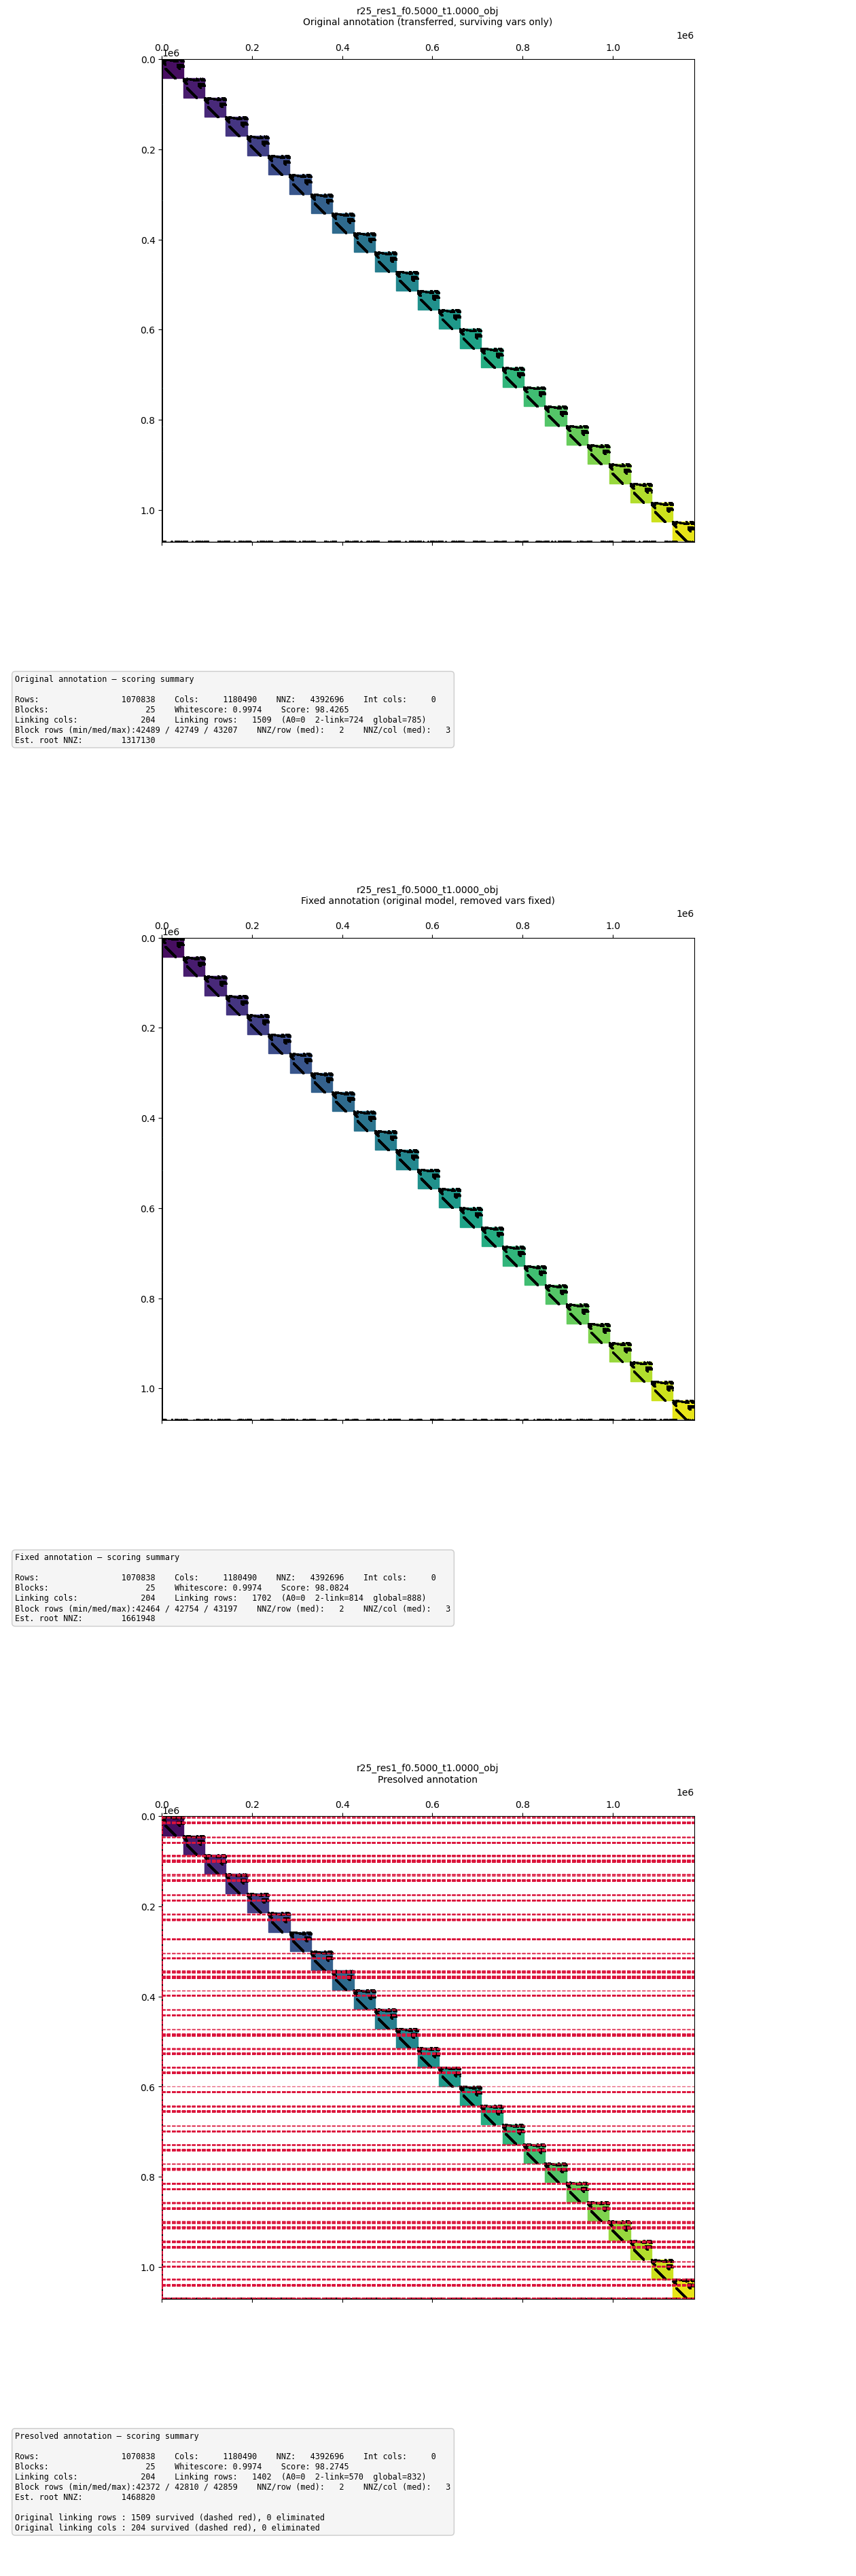

In [6]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SKIP_BLOCKS = False
COLORMAP    = 'viridis'

elim_note = [
    f'Original linking rows : {len(surviving_linking_rows)} survived (dashed red), '
    f'{len(eliminated_linking_rows)} eliminated',
    f'Original linking cols : {len(surviving_linking_cols)} survived (dashed red), '
    f'{len(eliminated_linking_cols)} eliminated',
]

fig = plt.figure(figsize=(16, 48))
gs  = GridSpec(6, 1, figure=fig, height_ratios=[5, 1.5, 5, 1.5, 5, 1.5], hspace=0.4)

ax1      = fig.add_subplot(gs[0])
ax_info1 = fig.add_subplot(gs[1])
ax2      = fig.add_subplot(gs[2])
ax_info2 = fig.add_subplot(gs[3])
ax3      = fig.add_subplot(gs[4])
ax_info3 = fig.add_subplot(gs[5])

plot_partition(
    ax1, A_pre, cols_orig_on_pre, rows_orig_on_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title=f'{MODEL_NAME}\nOriginal annotation (transferred, surviving vars only)',
    # integer_col_names=int_cols_orig_on_pre,
)
plot_partition(
    ax2, A_pre, cols_fixed_on_pre, rows_fixed_on_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title=f'{MODEL_NAME}\nFixed annotation (original model, removed vars fixed)',
    # integer_col_names=int_cols_fixed_on_pre,
)
plot_partition(
    ax3, A_pre, cols_pre, rows_pre,
    colormap=COLORMAP, skip_blocks=SKIP_BLOCKS,
    title=f'{MODEL_NAME}\nPresolved annotation',
    highlight_row_names=surviving_linking_rows,
    highlight_col_names=surviving_linking_cols,
    # integer_col_names=int_cols_pre,
)

render_stats(ax_info1, stats_orig,  title='Original annotation — scoring summary')
render_stats(ax_info2, stats_fixed, title='Fixed annotation — scoring summary')
render_stats(ax_info3, stats_pre,   title='Presolved annotation — scoring summary',
             extra_lines=elim_note)

plt.show()


## PIPS-IPM++ solve comparison

Split each annotation of the **presolved** MPS into per-block GDX files, then solve
all three with PIPS-IPM++ and compare objective values and wall-clock times.

The original and fixed annotations both require `transfer=True` in `split_to_blocks`
since they describe the original model and must be remapped onto the presolved MPS.
The presolved annotation is used directly.

In [ ]:
import re
import subprocess
import time

import gamspy_base

from src.config import PIPS_PATH
from src.solvers.split import split_to_blocks

PIPS_TIMEOUT = None
GMSPIPS  = PIPS_PATH / 'build' / 'gmspips'
GAMS_DIR = gamspy_base.directory

BLOCKS_ORIG.mkdir(parents=True, exist_ok=True)
BLOCKS_PRE.mkdir(parents=True, exist_ok=True)
BLOCKS_FIXED.mkdir(parents=True, exist_ok=True)

# Case 1: original annotation transferred onto presolved MPS
print('[original] splitting ...')
n_orig = split_to_blocks(mps_pre, BLOCKS_ORIG, annotation_gdx=gdx_orig, transfer=True)
print(f'[original] {n_orig} diagonal blocks')

# Case 2: fixed annotation transferred onto presolved MPS (also an original-model annotation)
print('[fixed] splitting ...')
n_fixed_blocks = split_to_blocks(mps_pre, BLOCKS_FIXED, annotation_gdx=gdx_fixed, transfer=True)
print(f'[fixed] {n_fixed_blocks} diagonal blocks')

# Case 3: presolved annotation used directly
print('[presolved] splitting ...')
n_pre = split_to_blocks(mps_pre, BLOCKS_PRE, annotation_gdx=gdx_presolved)
print(f'[presolved] {n_pre} diagonal blocks')


def _run_pips(block_dir, n_diag, label):
    n_procs = min(n_diag + 1, MAX_MPI_PROCS)
    cmd = [
        'mpirun', '-np', str(n_procs),
        str(GMSPIPS), str(n_diag + 1),
        str(Path(block_dir) / f'block_{n_diag}b'),
        GAMS_DIR,
        'scaleGeo',
    ]
    print(f'\n[{label}] {" ".join(cmd)}')
    t0     = time.perf_counter()
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=PIPS_TIMEOUT)
    wall   = time.perf_counter() - t0
    out    = result.stdout + result.stderr
    m      = re.search(
        r'---Objective value:\s*([+-]?[0-9]*\.?[0-9]+(?:[eE][+-]?[0-9]+)?)', out
    )
    return {
        'label':      label,
        'objective':  float(m.group(1)) if m else None,
        'wall_time':  wall,
        'returncode': result.returncode,
        'stdout':     out,
    }


print('\n=== Running PIPS-IPM++ ===')
res_orig  = _run_pips(BLOCKS_ORIG,  n_orig,         'original annotation')
res_fixed = _run_pips(BLOCKS_FIXED, n_fixed_blocks, 'fixed annotation')
res_pre   = _run_pips(BLOCKS_PRE,   n_pre,          'presolved annotation')


[original] splitting ...
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Number of MI entries in BOUNDS section is 51
Number of PL entries in BOUNDS section is 961286
  transfer_partition: 0/1180489 vars unmatched, 0/1070837 rows unmatched (partition=0)


100%|██████████| 26/26 [00:07<00:00,  3.44it/s]


[original] 25 diagonal blocks
[fixed] splitting ...
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Number of MI entries in BOUNDS section is 51
Number of PL entries in BOUNDS section is 961286
  transfer_partition: 0/1180489 vars unmatched, 0/1070837 rows unmatched (partition=0)


100%|██████████| 26/26 [00:07<00:00,  3.44it/s]


[fixed] 25 diagonal blocks
[presolved] splitting ...


100%|██████████| 26/26 [00:07<00:00,  3.63it/s]


[presolved] 25 diagonal blocks

=== Running PIPS-IPM++ ===

[original annotation] mpirun -np 2 /homes/vm922/energy-system-preprocessing/src/solvers/PIPS-IPMpp/build/gmspips 26 /data/energy-system-preprocessing/blocks/r25_res1_f0.5000_t1.0000_obj/original/block_25b /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base scaleGeo


In [32]:
def _fmt(val, fmt='.6g'):
    return format(val, fmt) if val is not None else 'FAILED'


def _rel_diff(a, b):
    if a is None or b is None:
        return '—'
    ref = max(abs(a), abs(b), 1e-12)
    return f'{abs(a - b) / ref * 100:.4f}%'


results = [res_orig, res_fixed, res_pre]

print(f'  {"Annotation":<26} {"Objective":>16} {"Wall time (s)":>14} {"Exit":>5}')
print(f'  {"-" * 64}')
for r in results:
    print(f'  {r["label"]:<26} {_fmt(r["objective"]):>16} {r["wall_time"]:>14.1f} {r["returncode"]:>5}')

print()
ref_obj = res_pre['objective']
for r in [res_orig, res_fixed]:
    print(f'  Objective vs presolved ({r["label"]:<22}): {_rel_diff(r["objective"], ref_obj)}')

print()
if res_orig['wall_time'] > 0:
    for r in [res_fixed, res_pre]:
        speedup = res_orig['wall_time'] / r['wall_time']
        print(f'  Wall-time speedup ({r["label"]:<26}): {speedup:.2f}×  (vs original)')

for r in results:
    if r['objective'] is None:
        print(f'\n--- raw stdout/stderr [{r["label"]}] ---')
        print(r['stdout'][:3000])


  Annotation                        Objective  Wall time (s)  Exit
  ----------------------------------------------------------------
  original annotation                 97.9503            1.6     0
  fixed annotation                    97.9501            1.1     0
  presolved annotation                 FAILED            1.2   139

  Objective vs presolved (original annotation   ): —
  Objective vs presolved (fixed annotation      ): —

  Wall-time speedup (fixed annotation          ): 1.42×  (vs original)
  Wall-time speedup (presolved annotation      ): 1.30×  (vs original)

--- raw stdout/stderr [presolved annotation] ---
reading /data/energy-system-preprocessing/blocks/benchmarks/MIPLIB/30n20b8/reduced/block_3b
GAMS located at /homes/vm922/espenv/lib/python3.12/site-packages/gamspy_base
Using a total of 1 MPI processes.
Using outer BICGSTAB
Creating PIPSIpmInterface ...
Zero joint variable count!
*** 4248 unexpected matrix coefficient var.stage <> equ.stage and not linking. Add -